# Fraud Detection — End-to-End Pipeline
This notebook covers:
1. Data loading & exploration (EDA)
2. Feature engineering & preprocessing
3. Model training with SMOTE resampling
4. Evaluation & comparison of multiple classifiers
5. Ensemble / stacking model
6. Cross-dataset generalisation test

## 1. Setup

In [ ]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import kagglehub

from scipy.stats import ttest_ind

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    StackingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

## 2. Data Loading

In [ ]:
path = kagglehub.dataset_download("amanalisiddiqui/fraud-detection-dataset")
df = pd.read_csv(os.path.join(path, "AIML Dataset.csv"))

print(f"Shape: {df.shape}")
print(f"\nFraud rate: {df['isFraud'].mean():.4%}")
df.head()

Using Colab cache for faster access to the 'fraud-detection-dataset' dataset.
Shape: (6362620, 11)

Fraud rate: 0.1291%


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.6400,C1231006815,170136.0000,160296.3600,M1979787155,0.0000,0.0000,0,0
1,1,PAYMENT,1864.2800,C1666544295,21249.0000,19384.7200,M2044282225,0.0000,0.0000,0,0
2,1,TRANSFER,181.0000,C1305486145,181.0000,0.0000,C553264065,0.0000,0.0000,1,0
3,1,CASH_OUT,181.0000,C840083671,181.0000,0.0000,C38997010,21182.0000,0.0000,1,0
4,1,PAYMENT,11668.1400,C2048537720,41554.0000,29885.8600,M1230701703,0.0000,0.0000,0,0


## 3. Exploratory Data Analysis (EDA)

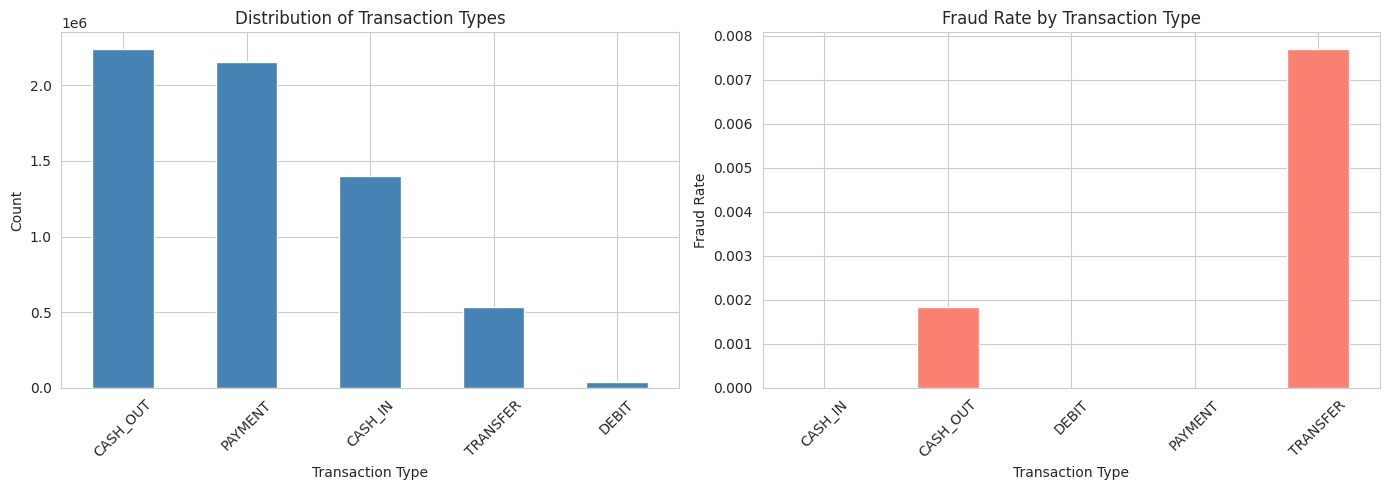


Key insight: All fraud is concentrated in TRANSFER and CASH_OUT transactions.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transaction type distribution
df['type'].value_counts().plot(kind='bar', color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of Transaction Types')
axes[0].set_xlabel('Transaction Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Fraud rate per transaction type
fraud_by_type = df.groupby('type')['isFraud'].mean()
fraud_by_type.plot(kind='bar', color='salmon', ax=axes[1])
axes[1].set_title('Fraud Rate by Transaction Type')
axes[1].set_xlabel('Transaction Type')
axes[1].set_ylabel('Fraud Rate')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nKey insight: All fraud is concentrated in TRANSFER and CASH_OUT transactions.")

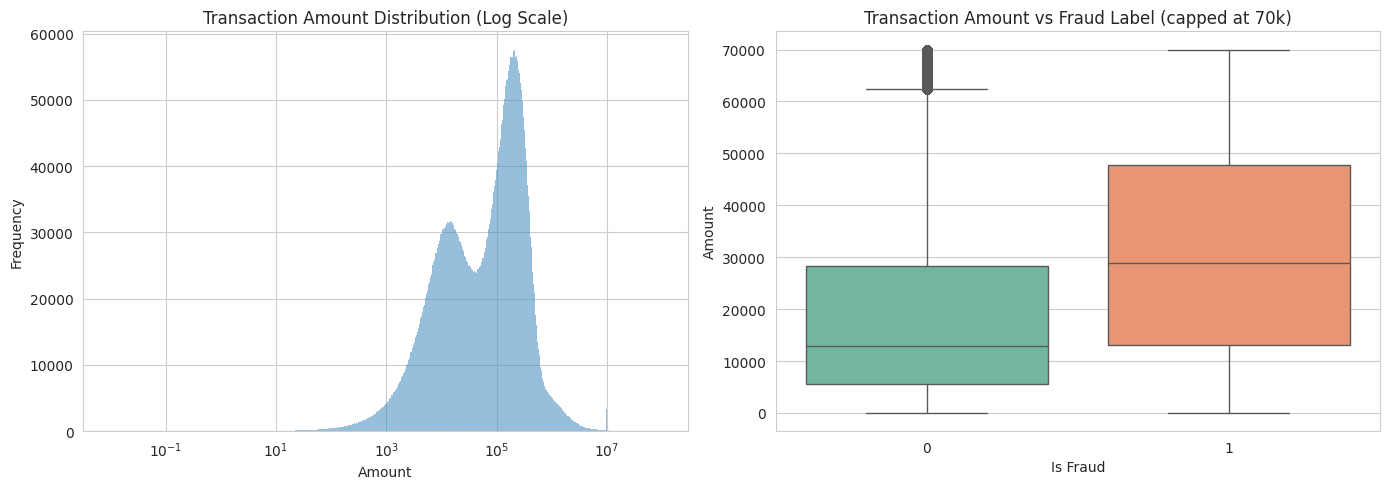

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transaction amount distribution (log scale)
sns.histplot(df['amount'], kde=True, log_scale=True, ax=axes[0])
axes[0].set_title('Transaction Amount Distribution (Log Scale)')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')

# Amount by fraud label (capped at 70k for readability)
sns.boxplot(
    data=df[df['amount'] < 70_000],
    x='isFraud', y='amount',
    palette='Set2', ax=axes[1]
)
axes[1].set_title('Transaction Amount vs Fraud Label (capped at 70k)')
axes[1].set_xlabel('Is Fraud')
axes[1].set_ylabel('Amount')

plt.tight_layout()
plt.show()

In [ ]:
# Statistical test: do fraud and non-fraud transactions differ in amount?
legit  = df[df['isFraud'] == 0]['amount'].dropna()
fraud  = df[df['isFraud'] == 1]['amount'].dropna()

t_stat, p_val = ttest_ind(legit, fraud)

# Cohen's d (effect size)
cohens_d = (legit.mean() - fraud.mean()) / ((legit.std() + fraud.std()) / 2)

print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_val:.4e}")
print(f"Cohen's d   : {cohens_d:.4f}")
print("\nConclusion: Amount is a statistically significant feature for fraud detection.")

T-statistic : -194.0120
P-value     : 0.0000e+00
Cohen's d   : -0.8597

Conclusion: Amount is a statistically significant feature for fraud detection.


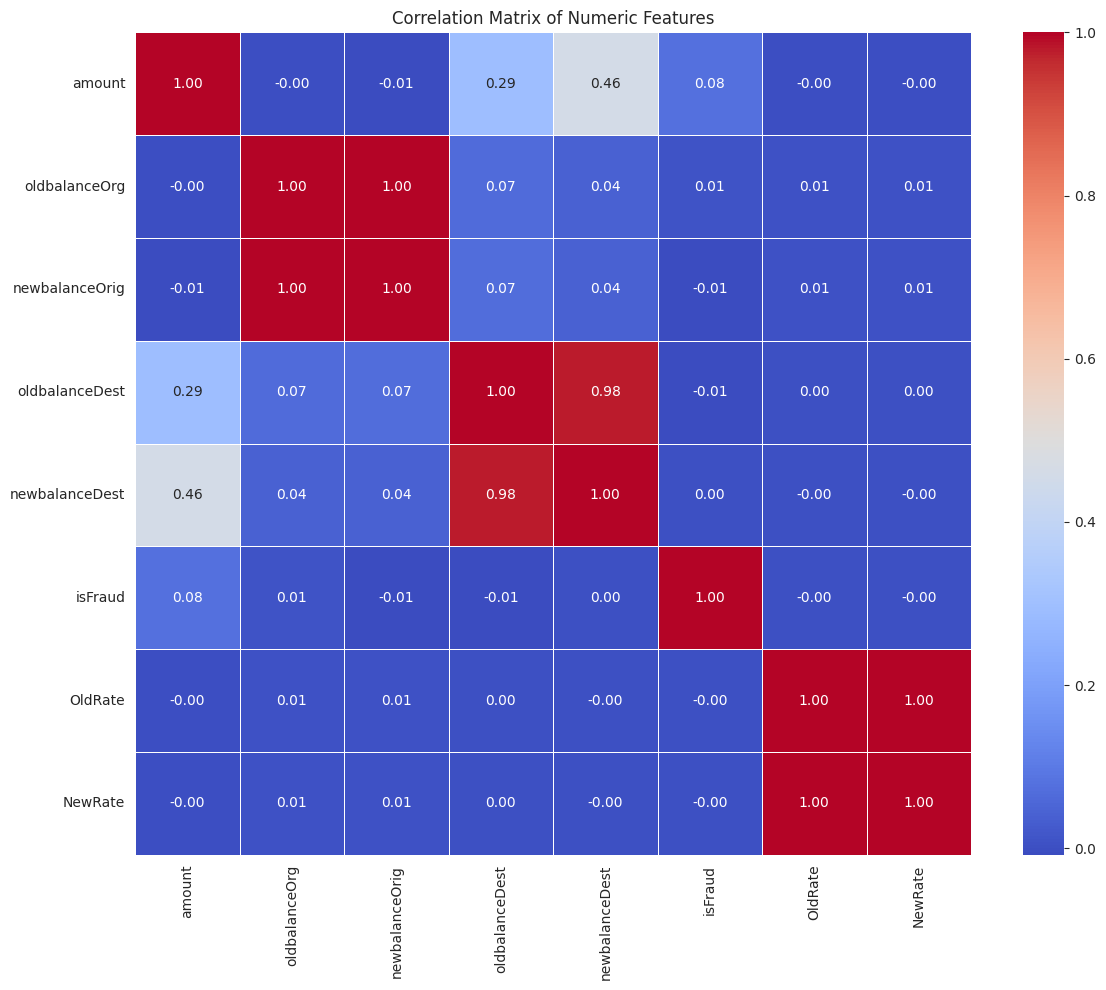

In [ ]:
# Correlation heatmap (with engineered ratio features)
df_corr = df.drop(columns=['step', 'isFlaggedFraud'])
df_corr['OldRate'] = df_corr['oldbalanceOrg'] / df_corr['amount'].replace(0, np.nan)
df_corr['NewRate'] = df_corr['newbalanceOrig'] / df_corr['amount'].replace(0, np.nan)

numeric_cols  = df_corr.select_dtypes(include=[np.number]).columns
corr_matrix   = df_corr[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [ ]:
# Drop columns that leak information or are identifiers
DROP_COLS = ['step', 'nameOrig', 'nameDest', 'isFlaggedFraud']

CATEGORICAL_FEATURES = ['type']
NUMERICAL_FEATURES   = [
    'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest'
]

X = df.drop(columns=DROP_COLS + ['isFraud'])
y = df['isFraud']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_FEATURES),
        ('num', StandardScaler(), NUMERICAL_FEATURES),
    ],
    remainder='drop'
)

print(f"Feature matrix shape: {X.shape}")
print(f"Class distribution:\n{y.value_counts()}")

Feature matrix shape: (6362620, 6)
Class distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [ ]:
X_transformed = preprocessor.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_transformed, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set size : {X_train.shape[0]:,}")
print(f"Test set size     : {X_test.shape[0]:,}")
print(f"Class balance: {y.value_counts().to_dict()}")

Training set size : 5,090,096
Test set size     : 1,272,524
Class balance: {0: 6354407, 1: 8213}


## 5. Model Training & Comparison

In [ ]:
MODELS = {
    "Logistic Regression" : LogisticRegression(C=1.0, solver='liblinear', max_iter=500, class_weight='balanced'),
    "Decision Tree"       : DecisionTreeClassifier(random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost"             : XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
    "LightGBM"            : LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    "KNN"                 : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
}

results        = {}
trained_models = {}

for name, model in MODELS.items():
    print(f"Training {name}...", end=" ")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    report = classification_report(y_test, preds, output_dict=True)
    results[name]        = report
    trained_models[name] = model
    print(f"F1 (fraud class): {report['1']['f1-score']:.4f}")

print("\nAll models trained.")

Training Logistic Regression... F1 (fraud class): 0.0435
Training Decision Tree... F1 (fraud class): 0.9020
Training Random Forest... F1 (fraud class): 0.8666
Training XGBoost... F1 (fraud class): 0.8069
Training LightGBM... F1 (fraud class): 0.1205
Training KNN... F1 (fraud class): 0.8311

All models trained.


In [ ]:
# Summary table: accuracy, precision, recall, F1 for the fraud class (label = 1)
summary = pd.DataFrame([
    {
        'Model'     : name,
        'Accuracy'  : report['accuracy'],
        'Precision' : report['1']['precision'],
        'Recall'    : report['1']['recall'],
        'F1-Score'  : report['1']['f1-score'],
    }
    for name, report in results.items()
]).set_index('Model').sort_values('F1-Score', ascending=False)

print("\n=== Model Comparison (fraud class) ===")
summary


=== Model Comparison (fraud class) ===


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Decision Tree,0.9997,0.9050,0.8990,0.9020
Random Forest,0.9997,0.9614,0.7888,0.8666
KNN,0.9996,0.9339,0.7486,0.8311
XGBoost,0.9995,0.8923,0.7365,0.8069
LightGBM,0.9969,0.0953,0.1637,0.1205
Logistic Regression,0.9465,0.0223,0.9434,0.0435


## 6. Stacking Ensemble Model
We combine XGBoost and Random Forest as base learners in a stacking classifier,
using their predicted probabilities as meta-features.

In [ ]:
stacked_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', StackingClassifier(
        estimators=[
            ('xgb', XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1)),
            ('rf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
        ],
        stack_method='predict_proba',
        cv=3,
        n_jobs=-1
    ))
])

# Re-use the original (non-SMOTE) split so the pipeline handles preprocessing internally
X_raw_train, X_raw_test, y_raw_train, y_raw_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Fitting stacked model...")
stacked_model.fit(X_raw_train, y_raw_train)
print("Done.")

In [ ]:
# Default threshold evaluation
stacked_preds = stacked_model.predict(X_raw_test)
print("=== Stacked Model — Default Threshold (0.5) ===")
print(classification_report(y_raw_test, stacked_preds))

In [ ]:
# Custom threshold: lower threshold boosts recall at the cost of precision
THRESHOLD = 0.30

stacked_probs  = stacked_model.predict_proba(X_raw_test)[:, 1]
stacked_preds_t = (stacked_probs >= THRESHOLD).astype(int)

print(f"=== Stacked Model — Custom Threshold ({THRESHOLD}) ===")
print(classification_report(y_raw_test, stacked_preds_t))

In [ ]:
# Save the stacked pipeline for downstream use (e.g., Streamlit app)
joblib.dump(stacked_model, 'stacked_fraud_detection_pipeline.pkl')
print("Stacked pipeline saved → stacked_fraud_detection_pipeline.pkl")

## 7. Generalisation Test on External Dataset
We load a second fraud dataset from Kaggle to verify that the pipeline
generalises beyond the training distribution.

In [ ]:
ext_path = kagglehub.dataset_download("chitwanmanchanda/fraudulent-transactions-data")
df_ext   = pd.read_csv(os.path.join(ext_path, "Fraud.csv"))

print(f"External dataset shape : {df_ext.shape}")
print(f"Fraud rate             : {df_ext['isFraud'].mean():.4%}")
df_ext.head()

In [ ]:
# Align columns with training features
X_ext = df_ext.drop(columns=DROP_COLS + ['isFraud'], errors='ignore')
y_ext = df_ext['isFraud']

ext_preds = stacked_model.predict(X_ext)

print("=== Stacked Model — External Dataset ===")
print(classification_report(y_ext, ext_preds))